# Predicting PM2.5 in London Output Areas using Graph Neural Networks

## 1.Data exploration

### 1.1 Data structure and quality

The dataset was checked for structure, geometry, coordinate system and missing values to ensure suitability for spatial analysis.

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 12

In [3]:
file_path = "AssignmentData-LondonPM25Prediction.geojson"
gdf = gpd.read_file(file_path)


print("Shape:", gdf.shape)

Shape: (25053, 63)


In [38]:
gdf.head()

,oa_code,PM25,k001_PCT,k002_PCT,k003_PCT,k004_PCT,k005_PCT,k006_PCT,k007_RATIO,k008_PCT,...,k052_PCT,k053_PCT,k054_PCT,k055_PCT,k056_PCT,k057_PCT,k058_PCT,k059_PCT,k060_PCT,geometry
0,E00023264,16.037363,0.655567,0.733280,0.788337,0.809438,0.616867,0.048672,0.497994,0.116873,...,0.801915,0.574316,0.565354,0.693873,0.607090,0.478002,0.509235,0.638862,0.662914,"MULTIPOLYGON (((527635.452 171810.058, 527495...."
1,E00003359,15.571575,0.747233,0.539689,0.833211,0.720010,0.659997,0.155885,0.389216,0.387319,...,0.731722,0.346726,0.750254,0.730786,0.669715,0.548814,0.621092,0.667940,0.558571,"MULTIPOLYGON (((543581.516 171132.486, 543704 ..."
2,E00023266,16.068834,0.689326,0.758308,0.780265,0.787414,0.633875,0.151961,0.542225,0.000000,...,0.789704,0.603182,0.551503,0.630910,0.562070,0.614731,0.500493,0.624021,0.682385,"MULTIPOLYGON (((526613.539 171839.165, 526546...."
3,E00020264,18.205215,0.749280,0.701306,0.841211,0.773311,0.432955,0.000000,0.480711,0.000000,...,0.712008,0.454649,0.413096,0.740138,0.831888,0.726281,0.377247,0.517599,0.540406,"MULTIPOLYGON (((533563.521 179695.146, 533351...."
4,E00023263,16.128491,0.716956,0.743201,0.823621,0.783315,0.621155,0.073256,0.532274,0.000000,...,0.752003,0.656612,0.372115,0.741299,0.555038,0.692244,0.524108,0.657307,0.614341,"MULTIPOLYGON (((527822 172020, 527979 171903.0..."


In [39]:
print("Columns:")
print(gdf.columns.tolist())

Columns:
['oa_code', 'PM25', 'k001_PCT', 'k002_PCT', 'k003_PCT', 'k004_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k008_PCT', 'k009_PCT', 'k010_PCT', 'k011_PCT', 'k012_PCT', 'k013_PCT', 'k014_PCT', 'k015_PCT', 'k016_PCT', 'k017_PCT', 'k018_PCT', 'k019_PCT', 'k020_PCT', 'k021_PCT', 'k022_PCT', 'k023_PCT', 'k024_PCT', 'k025_PCT', 'k026_PCT', 'k027_PCT', 'k028_PCT', 'k029_PCT', 'k030_PCT', 'k031_PCT', 'k032_PCT', 'k033_PCT', 'k034_PCT', 'k035_RATIO', 'k036_PCT', 'k037_PCT', 'k038_PCT', 'k039_PCT', 'k040_PCT', 'k041_PCT', 'k042_PCT', 'k043_PCT', 'k044_PCT', 'k045_PCT', 'k046_PCT', 'k047_PCT', 'k048_PCT', 'k049_PCT', 'k050_PCT', 'k051_PCT', 'k052_PCT', 'k053_PCT', 'k054_PCT', 'k055_PCT', 'k056_PCT', 'k057_PCT', 'k058_PCT', 'k059_PCT', 'k060_PCT', 'geometry']


In [40]:
print("CRS:", gdf.crs)

CRS: EPSG:27700


In [41]:
print(gdf.geometry.geom_type.value_counts())

MultiPolygon    25053
Name: count, dtype: int64


In [42]:
missing_values = gdf.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

Series([], dtype: int64)

The dataset contains 25,053 spatial units and 63 columns, stored as MultiPolygons in the British National Grid coordinate system (EPSG:27700), with no missing values.

### 1.2 PM2.5 distribution and spatial pattern

In [43]:
print("PM2.5 Summary Statistics")
print(gdf["PM25"].describe())

PM2.5 Summary Statistics
count    25053.000000
mean        15.975608
std          0.783971
min         14.283266
25%         15.403583
50%         15.846878
75%         16.428663
max         21.100099
Name: PM25, dtype: float64


Descriptive statistics show that PM2.5 values range from 14.28 to 21.10, with a mean of 15.98 and a standard deviation of 0.78. 

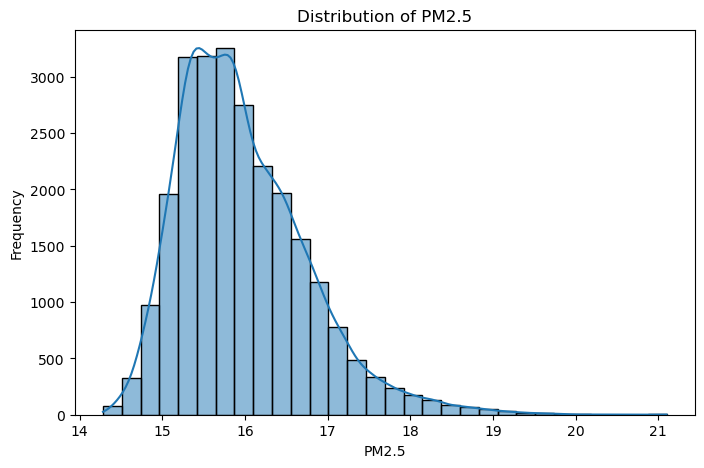

In [44]:
plt.figure(figsize=(8, 5))
sns.histplot(gdf["PM25"], bins=30, kde=True)
plt.title("Distribution of PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.show()

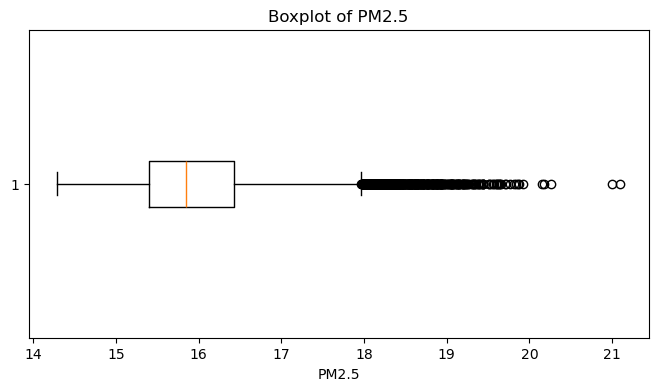

In [45]:
plt.figure(figsize=(8, 4))
plt.boxplot(gdf["PM25"], vert=False)
plt.title("Boxplot of PM2.5")
plt.xlabel("PM2.5")
plt.show()

The histogram suggests a moderately right-skewed distribution, while the boxplot indicates the presence of several high-value outliers.

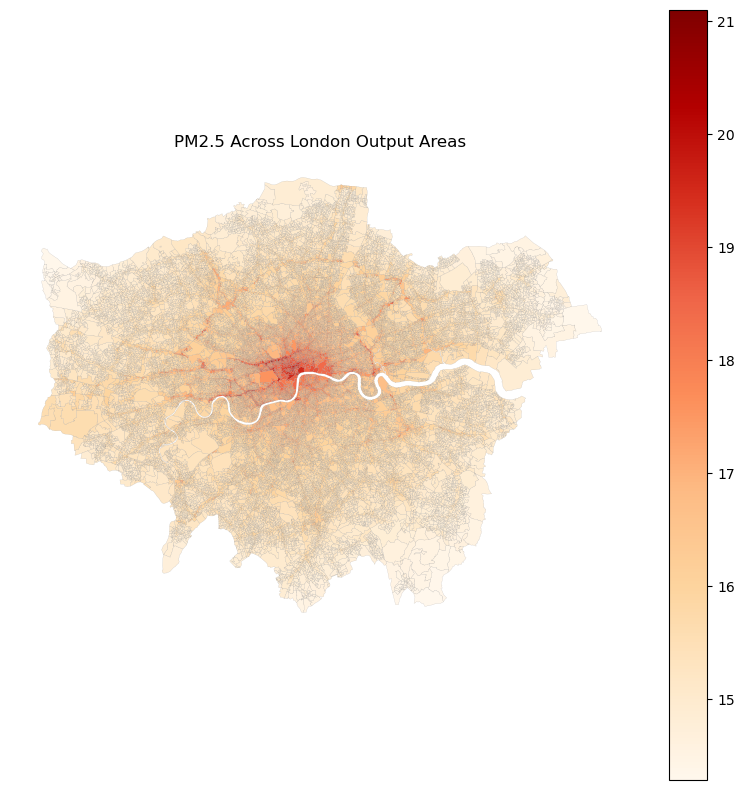

In [46]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
gdf.plot(column="PM25", cmap="OrRd", linewidth=0.08, edgecolor="grey", legend=True, ax=ax)
ax.set_title("PM2.5 Across London Output Areas")
ax.axis("off")
plt.show()

The map indicates clear spatial variation in PM2.5 across London. Higher concentrations appear to be more concentrated in central areas, whereas lower values are more common towards the outer parts of the city. This pattern suggests that spatial dependence may be relevant for later modelling.

In [47]:
exclude_cols = ["oa_code", "PM25", "geometry"]

feature_cols = [col for col in gdf.columns
                if col not in exclude_cols and pd.api.types.is_numeric_dtype(gdf[col])]

print("Number of candidate input features:", len(feature_cols))
print("First 10 feature columns:", feature_cols[:10])

Number of candidate input features: 60
First 10 feature columns: ['k001_PCT', 'k002_PCT', 'k003_PCT', 'k004_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k008_PCT', 'k009_PCT', 'k010_PCT']


These variables were retained as node attributes for the later graph-based model.

## 2.Graph Construction

### 2.1 Building the adjacency graph

In [5]:
graph_gdf = gdf.copy().reset_index(drop=True)
graph_gdf["node_id"] = graph_gdf.index

print("Graph GeoDataFrame shape:", graph_gdf.shape)
print("First 5 node IDs:")
print(graph_gdf[["node_id", "oa_code", "PM25"]].head())

Graph GeoDataFrame shape: (25053, 64)
First 5 node IDs:
   node_id    oa_code       PM25
0        0  E00023264  16.037363
1        1  E00003359  15.571575
2        2  E00023266  16.068834
3        3  E00020264  18.205215
4        4  E00023263  16.128491


In [6]:
adj_gdf = graph_gdf[["node_id", "geometry"]].copy()

print(adj_gdf.head())
print("Number of rows:", len(adj_gdf))

   node_id                                           geometry
0        0  MULTIPOLYGON (((527635.452 171810.058, 527495....
1        1  MULTIPOLYGON (((543581.516 171132.486, 543704 ...
2        2  MULTIPOLYGON (((526613.539 171839.165, 526546....
3        3  MULTIPOLYGON (((533563.521 179695.146, 533351....
4        4  MULTIPOLYGON (((527822 172020, 527979 171903.0...
Number of rows: 25053


Each Output Area was assigned a unique integer node_id, and a reduced GeoDataFrame containing only node identifiers and polygon geometries was used for adjacency construction.

In [7]:
adj_pairs = gpd.sjoin(
    adj_gdf,
    adj_gdf,
    how="inner",
    predicate="touches"
)

print(adj_pairs.head())
print("Number of candidate adjacency pairs:", len(adj_pairs))

   node_id_left                                           geometry  \
0             0  MULTIPOLYGON (((527635.452 171810.058, 527495....   
0             0  MULTIPOLYGON (((527635.452 171810.058, 527495....   
0             0  MULTIPOLYGON (((527635.452 171810.058, 527495....   
0             0  MULTIPOLYGON (((527635.452 171810.058, 527495....   
0             0  MULTIPOLYGON (((527635.452 171810.058, 527495....   

   index_right  node_id_right  
0        18695          18695  
0        16631          16631  
0        18690          18690  
0          144            144  
0        19572          19572  
Number of candidate adjacency pairs: 151934


In [8]:
edges_df = adj_pairs[["node_id_left", "node_id_right"]].copy()

edges_df = edges_df[edges_df["node_id_left"] != edges_df["node_id_right"]]

edges_df["source"] = edges_df[["node_id_left", "node_id_right"]].min(axis=1)
edges_df["target"] = edges_df[["node_id_left", "node_id_right"]].max(axis=1)

edges_df = edges_df[["source", "target"]].drop_duplicates().reset_index(drop=True)

print(edges_df.head())
print("Number of unique undirected edges:", len(edges_df))

   source  target
0       0   18695
1       0   16631
2       0   18690
3       0     144
4       0   19572
Number of unique undirected edges: 75967


A spatial self-join was used to identify neighbouring Output Areas. Two polygons were treated as adjacent when their boundaries touched, after which self-loops were removed and duplicate pairs were collapsed to form an undirected edge list.

### 2.2 Graph summary statistics

After constructing the undirected edge list, several basic graph statistics were calculated to assess whether the adjacency structure was reasonable. These include the total number of nodes and edges, the average node degree, and the number of isolated nodes.

In [9]:
num_nodes = len(graph_gdf)
num_edges = len(edges_df)

avg_degree = 2 * num_edges / num_nodes

degree_counts = pd.concat([
    edges_df["source"],
    edges_df["target"]
]).value_counts().sort_index()

isolated_nodes = set(graph_gdf["node_id"]) - set(degree_counts.index)

print("Number of nodes:", num_nodes)
print("Number of undirected edges:", num_edges)
print("Average degree:", round(avg_degree, 2))
print("Number of isolated nodes:", len(isolated_nodes))

Number of nodes: 25053
Number of undirected edges: 75967
Average degree: 6.06
Number of isolated nodes: 0


In [10]:
degree_summary = degree_counts.describe()
print(degree_summary)

count    25053.000000
mean         6.064503
std          1.993320
min          1.000000
25%          5.000000
50%          6.000000
75%          7.000000
max         28.000000
Name: count, dtype: float64


The resulting graph has an average degree of 6.06 and no isolated nodes, suggesting that the adjacency structure is well connected and suitable for modelling.

### 2.3 Local graph visualisation and interpretation

To visualise the graph structure, a centroid was calculated for each Output Area polygon. These centroids provide a simple point-based representation of node locations for plotting adjacency edges.

In [11]:
graph_gdf["centroid"] = graph_gdf.geometry.centroid

print(graph_gdf[["node_id", "centroid"]].head())

   node_id                       centroid
0        0  POINT (527526.428 171947.689)
1        1  POINT (543811.648 170949.578)
2        2  POINT (526679.771 171864.076)
3        3   POINT (533513.69 179855.843)
4        4  POINT (527863.192 171936.823)


To avoid an overly dense visualisation, a smaller spatial window was selected from the full study area. 

In [12]:
xmin, ymin, xmax, ymax = graph_gdf.total_bounds

print("Total bounds:")
print(xmin, ymin, xmax, ymax)

Total bounds:
503574.188 155850.798 561956.688 200933.609


In [13]:
x1 = xmin + 0.40 * (xmax - xmin)
x2 = xmin + 0.60 * (xmax - xmin)
y1 = ymin + 0.40 * (ymax - ymin)
y2 = ymin + 0.60 * (ymax - ymin)

local_gdf = graph_gdf.cx[x1:x2, y1:y2].copy()

print("Local area shape:", local_gdf.shape)
print(local_gdf[["node_id", "oa_code"]].head())

Local area shape: (3632, 65)
    node_id    oa_code
3         3  E00020264
13       13  E00019889
14       14  E00019888
16       16  E00019808
19       19  E00020267


A smaller window was extracted from the central part of the study area for graph visualisation. This avoids excessive overlap and makes the local adjacency structure easier to interpret.

In [14]:
local_node_ids = set(local_gdf["node_id"])

local_edges = edges_df[
    edges_df["source"].isin(local_node_ids) &
    edges_df["target"].isin(local_node_ids)
].copy()

print("Local nodes:", len(local_gdf))
print("Local undirected edges:", len(local_edges))
print(local_edges.head())

Local nodes: 3632
Local undirected edges: 10744
    source  target
16       3   19567
17       3      21
18       3   17371
19       3    5819
20       3    5591


The global edge list was then filtered so that only edges connecting nodes within the selected local window were retained. This produced a smaller subgraph for visualisation.

In [17]:
local_gdf["x"] = local_gdf["centroid"].x
local_gdf["y"] = local_gdf["centroid"].y

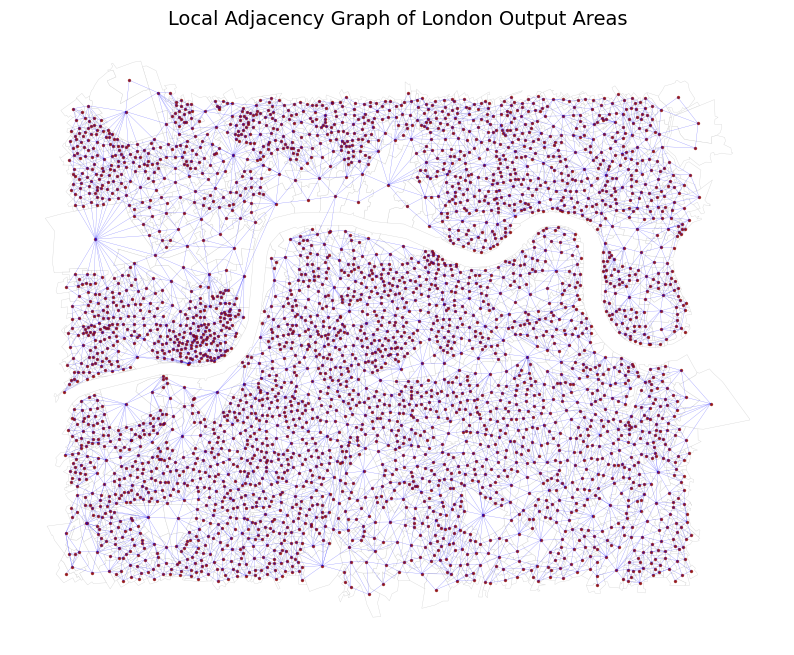

In [26]:
pos_dict = local_gdf.set_index("node_id")[["x", "y"]].to_dict("index")

fig, ax = plt.subplots(figsize=(10, 10))

local_gdf.plot(ax=ax, color="white", edgecolor="lightgrey", linewidth=0.25)

for _, row in local_edges.iterrows():
    s = row["source"]
    t = row["target"]
    
    x_values = [pos_dict[s]["x"], pos_dict[t]["x"]]
    y_values = [pos_dict[s]["y"], pos_dict[t]["y"]]
    
    ax.plot(x_values, y_values, color="blue", linewidth=0.2, alpha=0.5)

ax.scatter(local_gdf["x"], local_gdf["y"], s=2, color="darkred", alpha=0.75)

ax.set_title("Local Adjacency Graph of London Output Areas", fontsize=14)
ax.set_axis_off()
plt.show()

A local subgraph was plotted to illustrate the adjacency structure more clearly. Each Output Area is represented by its centroid, while edges connect neighbouring polygons that share a boundary. The visualisation shows a dense network, with most nodes linked to several nearby areas rather than to distant locations.

The adjacency graph was chosen because neighbouring Output Areas are likely to share similar environmental and urban characteristics. Boundary-sharing relations provide a simple and interpretable representation of local spatial dependence relevant to PM2.5 prediction.

## 3.Graph Neural Network Model

### 3.1 Node features and data preparation

In [36]:
import torch
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

In [48]:
X = graph_gdf[feature_cols].values

y = graph_gdf["PM25"].values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", X.shape[1])

X shape: (25053, 60)
y shape: (25053,)
Number of features: 60


In [49]:
edge_index_np = edges_df[["source", "target"]].values.T

print("edge_index shape:", edge_index_np.shape)
print(edge_index_np[:, :5])

edge_index shape: (2, 75967)
[[    0     0     0     0     0]
 [18695 16631 18690   144 19572]]


In [50]:
edge_index_bidirectional = np.hstack([
    edge_index_np,
    edge_index_np[::-1]
])

print("Bidirectional edge_index shape:", edge_index_bidirectional.shape)
print(edge_index_bidirectional[:, :10])

Bidirectional edge_index shape: (2, 151934)
[[    0     0     0     0     0     0     1     1     1     1]
 [18695 16631 18690   144 19572 16629  4811 14147 22894 22893]]


In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled X shape:", X_scaled.shape)
print("Feature means (first 5):", X_scaled.mean(axis=0)[:5])
print("Feature stds (first 5):", X_scaled.std(axis=0)[:5])

Scaled X shape: (25053, 60)
Feature means (first 5): [ 1.24790965e-16  3.38637300e-16 -5.36601148e-16  1.49352095e-15
 -7.20384205e-16]
Feature stds (first 5): [1. 1. 1. 1. 1.]


In [52]:
num_nodes = X_scaled.shape[0]
all_indices = np.arange(num_nodes)

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42
)

print("Number of training nodes:", len(train_idx))
print("Number of testing nodes:", len(test_idx))

Number of training nodes: 20042
Number of testing nodes: 5011


The node feature matrix was constructed from the 60 numeric attribute columns identified in Step 1, while PM2.5 was used as the regression target. Before model training, the feature matrix was standardised using z-score scaling to place all variables on a comparable scale and improve training stability. The nodes were then divided into training and testing subsets using an 80:20 split.

### 3.2 Graph data construction

In [53]:
x_tensor = torch.tensor(X_scaled, dtype=torch.float)
y_tensor = torch.tensor(y, dtype=torch.float)
edge_index_tensor = torch.tensor(edge_index_bidirectional, dtype=torch.long)

print("x tensor shape:", x_tensor.shape)
print("y tensor shape:", y_tensor.shape)
print("edge_index tensor shape:", edge_index_tensor.shape)

x tensor shape: torch.Size([25053, 60])
y tensor shape: torch.Size([25053])
edge_index tensor shape: torch.Size([2, 151934])


In [54]:
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
test_mask[test_idx] = True

print("Training nodes in mask:", train_mask.sum().item())
print("Testing nodes in mask:", test_mask.sum().item())

Training nodes in mask: 20042
Testing nodes in mask: 5011


In [55]:
data = Data(
    x=x_tensor,
    edge_index=edge_index_tensor,
    y=y_tensor
)

data.train_mask = train_mask
data.test_mask = test_mask

print(data)

Data(x=[25053, 60], edge_index=[2, 151934], y=[25053], train_mask=[25053], test_mask=[25053])


A PyTorch Geometric `Data` object was constructed to store the node features, graph edges, target values, and train-test masks in a single graph representation.

### 3.3 GCN model

A two-layer GCN was implemented in PyTorch Geometric. The model used the 60 numeric urban attributes as node features, the adjacency-based spatial graph as the edge structure, and PM2.5 as the regression target. The model was trained for 1500 epochs to ensure stable convergence while keeping the model structure unchanged.

In [78]:
class GCNRegressor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        
        return x.squeeze()

In [79]:
model = GCNRegressor(in_channels=data.x.shape[1], hidden_channels=32)

print(model)

GCNRegressor(
  (conv1): GCNConv(60, 32)
  (conv2): GCNConv(32, 1)
)


In [80]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

In [81]:
def train():
    model.train()
    optimizer.zero_grad()
    
    out = model(data)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [82]:
def evaluate():
    model.eval()
    
    with torch.no_grad():
        out = model(data)
        
        y_true = data.y[data.test_mask].cpu().numpy()
        y_pred = out[data.test_mask].cpu().numpy()
        
        rmse = mean_squared_error(y_true, y_pred) ** 0.5
        r2 = r2_score(y_true, y_pred)
    
    return rmse, r2

In [101]:
loss_history = []

for epoch in range(1, 1501):
    loss = train()
    loss_history.append(loss)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}")

Epoch 010, Loss: 0.3779
Epoch 020, Loss: 0.3832
Epoch 030, Loss: 0.3718
Epoch 040, Loss: 0.3652
Epoch 050, Loss: 0.3596
Epoch 060, Loss: 0.3561
Epoch 070, Loss: 0.3517
Epoch 080, Loss: 0.3478
Epoch 090, Loss: 0.3470
Epoch 100, Loss: 0.3459
Epoch 110, Loss: 0.3387
Epoch 120, Loss: 0.3337
Epoch 130, Loss: 0.3285
Epoch 140, Loss: 0.3252
Epoch 150, Loss: 0.3226
Epoch 160, Loss: 0.3219
Epoch 170, Loss: 0.3140
Epoch 180, Loss: 0.3123
Epoch 190, Loss: 0.3094
Epoch 200, Loss: 0.3034
Epoch 210, Loss: 0.3006
Epoch 220, Loss: 0.3036
Epoch 230, Loss: 0.2933
Epoch 240, Loss: 0.2904
Epoch 250, Loss: 0.2879
Epoch 260, Loss: 0.2834
Epoch 270, Loss: 0.2806
Epoch 280, Loss: 0.2805
Epoch 290, Loss: 0.2764
Epoch 300, Loss: 0.2728
Epoch 310, Loss: 0.2680
Epoch 320, Loss: 0.2650
Epoch 330, Loss: 0.2652
Epoch 340, Loss: 0.2615
Epoch 350, Loss: 0.2582
Epoch 360, Loss: 0.2530
Epoch 370, Loss: 0.2516
Epoch 380, Loss: 0.2495
Epoch 390, Loss: 0.2445
Epoch 400, Loss: 0.2419
Epoch 410, Loss: 0.2461
Epoch 420, Loss:

In [102]:
rmse, r2 = evaluate()

print("Test RMSE:", round(rmse, 4))
print("Test R^2:", round(r2, 4))

Test RMSE: 0.331
Test R^2: 0.8256


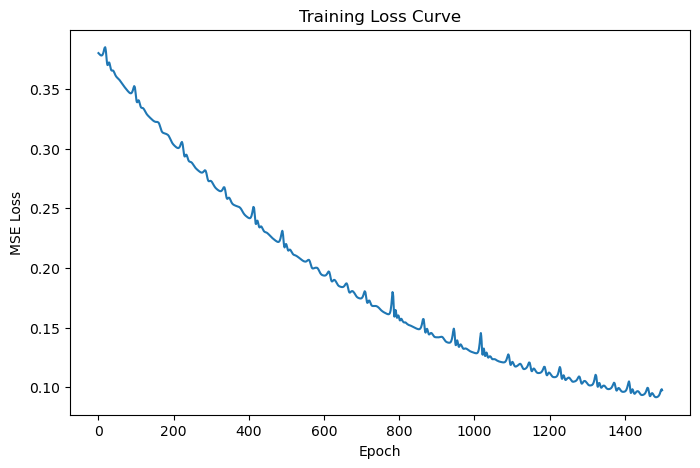

In [103]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

Model performance was evaluated on the test nodes using RMSE and R². The final GCN achieved an RMSE of 0.3310 and an R² of 0.8256. These results indicate strong predictive performance, suggesting that the combination of node attributes and spatial adjacency captured a substantial proportion of the variation in PM2.5 across London Output Areas.

### 3.4 Linear model

A linear regression model was used as a simple baseline for comparison with the GCN.

In [100]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_scaled[train_idx], y[train_idx])

lr_pred = lr_model.predict(X_scaled[test_idx])

lr_rmse = mean_squared_error(y[test_idx], lr_pred) ** 0.5
lr_r2 = r2_score(y[test_idx], lr_pred)

print("Linear Regression RMSE:", round(lr_rmse, 4))
print("Linear Regression R^2:", round(lr_r2, 4))

Linear Regression RMSE: 0.3843
Linear Regression R^2: 0.7649


### 3.5 Model comparison

The GCN and linear regression models were compared using RMSE and R² on the test set.

In [104]:
results_df = pd.DataFrame({
    "Model": ["GCN", "Linear Regression"],
    "RMSE": [rmse, lr_rmse],
    "R2": [r2, lr_r2]
})

results_df.round(4)

,Model,RMSE,R2
0,GCN,0.3310,0.8256
1,Linear Regression,0.3843,0.7649


GCN has lower RMSE and higher R² than linear regression. This means GCN provides more accurate predictions on the test set.

## 4.Results and Interpretation

#### 4.1 Prediction vs. actual plot

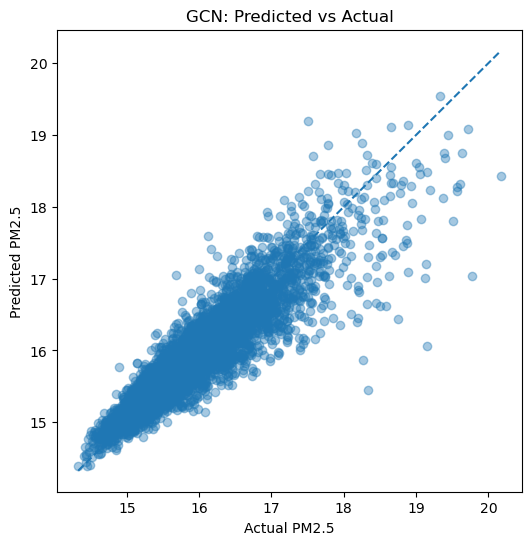

In [105]:
model.eval()
with torch.no_grad():
    gcn_pred_all = model(data).cpu().numpy()

gcn_pred_test = gcn_pred_all[test_idx]

plt.figure(figsize=(6, 6))
plt.scatter(y[test_idx], gcn_pred_test, alpha=0.4)
plt.plot(
    [y[test_idx].min(), y[test_idx].max()],
    [y[test_idx].min(), y[test_idx].max()],
    linestyle="--"
)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("GCN: Predicted vs Actual")
plt.show()

Most points are close to the diagonal line, which suggests that predicted values are generally close to actual values. Some larger deviations appear at higher PM2.5 values.

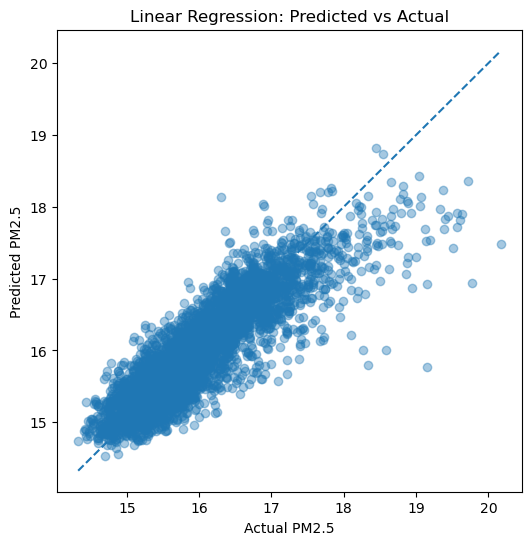

In [106]:
plt.figure(figsize=(6, 6))
plt.scatter(y[test_idx], lr_pred, alpha=0.4)
plt.plot(
    [y[test_idx].min(), y[test_idx].max()],
    [y[test_idx].min(), y[test_idx].max()],
    linestyle="--"
)
plt.xlabel("Actual PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("Linear Regression: Predicted vs Actual")
plt.show()

The same general trend is visible, but the points are more scattered. The model shows larger errors, especially in the higher-value range.

#### 4.2 Map of predicted PM2.5 values

In [113]:
model.eval()
with torch.no_grad():
    gcn_pred_all = model(data).cpu().numpy()

graph_gdf["gcn_pred"] = gcn_pred_all

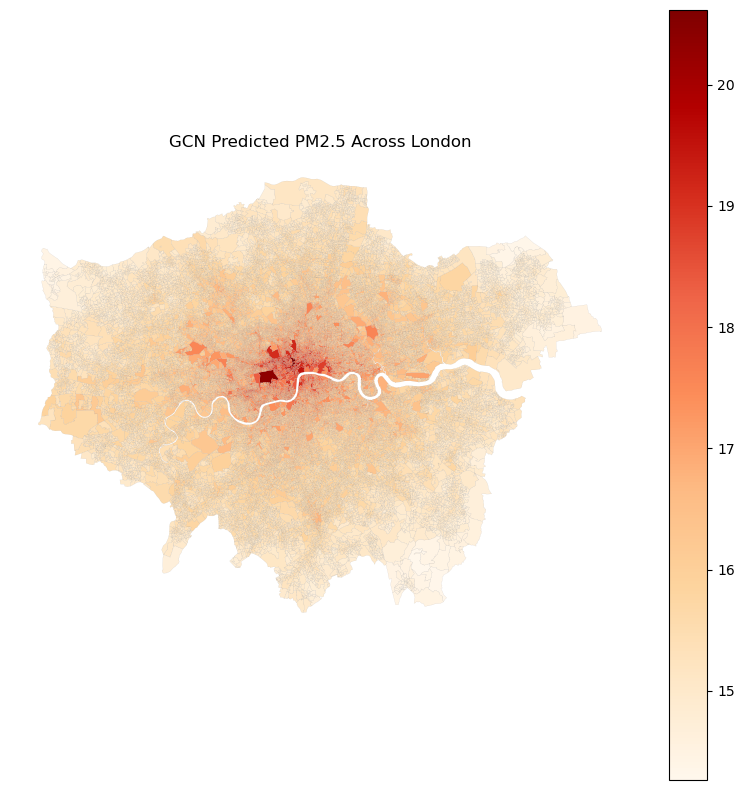

In [114]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
graph_gdf.plot(
    column="gcn_pred",
    cmap="OrRd",
    linewidth=0.05,
    edgecolor="grey",
    legend=True,
    ax=ax
)
ax.set_title("GCN Predicted PM2.5 Across London")
ax.axis("off")
plt.show()

Predicted PM2.5 values are higher in central London and lower in outer areas. Similar colours in neighbouring areas suggest that the model captures local spatial variation.

#### 4.3 Results interpretation

The GCN predicted-versus-actual plot shows a closer fit to the diagonal line than linear regression, which is consistent with its lower RMSE and higher R². This suggests that the GCN model predicts PM2.5 more accurately overall. However, both models show larger errors at higher PM2.5 values, indicating that extreme cases remain harder to predict. The predicted PM2.5 map also shows a clear spatial pattern across London. Higher values are concentrated in central areas, while lower values are more common in outer areas. This suggests that the GCN is capturing meaningful spatial variation, and it helps explain why the graph-based model performs better than the non-spatial baseline.

One limitation is that the random train-test split may still place nearby areas in both sets, so some spatial dependence may remain between training and testing data. In addition, higher PM2.5 values are harder to predict, suggesting that extreme local conditions are not fully captured by the available features.

### 5. Word count

In [120]:
import io
from nbformat import current

file_path = "./ATUA_Assignment_2.ipynb"

with io.open(file_path, 'r', encoding='utf-8') as f:
    nb = current.read(f, 'json')

word_count_markdown = 0
word_count_heading = 0
word_count_code = 0

for cell in nb.worksheets[0].cells:
    if cell.cell_type == "markdown":
        word_count_markdown += len(cell['source'].replace('#', '').lstrip().split())
    elif cell.cell_type == "heading":
        word_count_heading += len(cell['source'].replace('#', '').lstrip().split())
    elif cell.cell_type == "code":
        word_count_code += len(cell['input'].replace('#', '').lstrip().split())

print(file_path)
print("{} Words in notebooks' markdown".format(word_count_markdown))
print("{} Words in notebooks' heading".format(word_count_heading))
print("{} Words in notebooks' code".format(word_count_code))

./ATUA_Assignment_2.ipynb
923 Words in notebooks' markdown
74 Words in notebooks' heading
942 Words in notebooks' code
